In [2]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error

from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

import ta  # Technical Analysis Library

import matplotlib.pyplot as plt

import gym
from stable_baselines3 import DQN
from gym import spaces

Best Model: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Mean Absolute Error: 0.009530


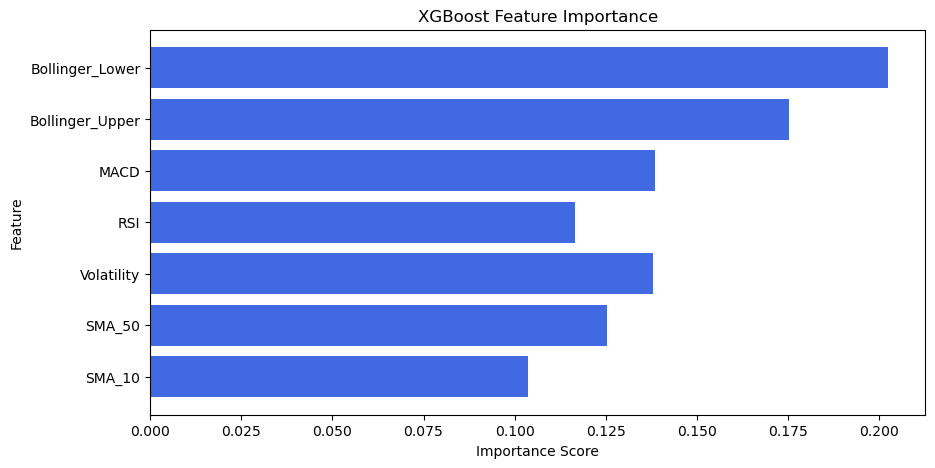

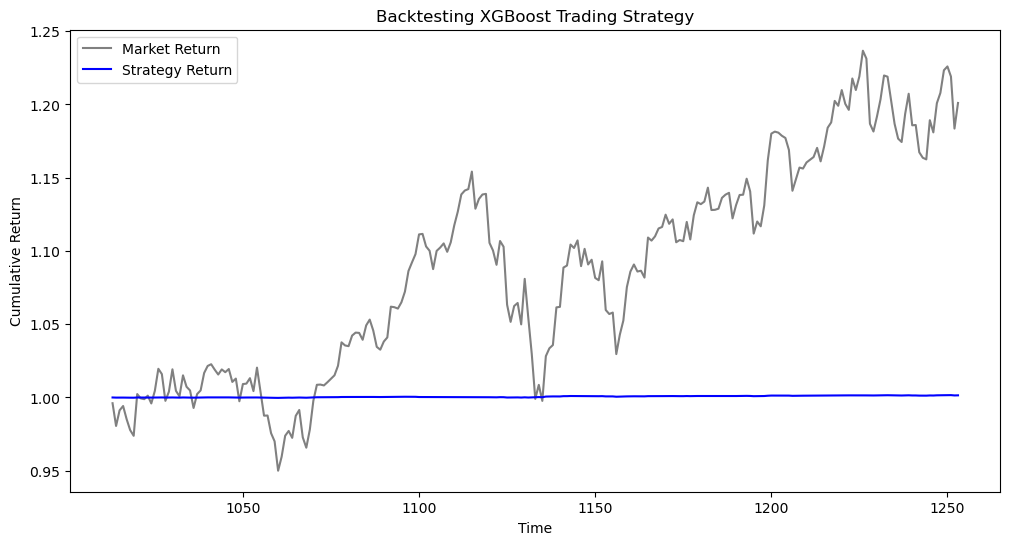

In [2]:
# XGBoost next day return prediction

df = pd.read_csv("qqq.csv")

# Feature Engineering
df["Return"] = df["close"].pct_change()
df["SMA_10"] = df["close"].rolling(window=10).mean()
df["SMA_50"] = df["close"].rolling(window=50).mean()
df["Volatility"] = df["Return"].rolling(window=10).std()
df["RSI"] = ta.momentum.RSIIndicator(df["close"], window=14).rsi()
df["MACD"] = ta.trend.MACD(df["close"]).macd()
df["Bollinger_Upper"] = ta.volatility.BollingerBands(df["close"]).bollinger_hband()
df["Bollinger_Lower"] = ta.volatility.BollingerBands(df["close"]).bollinger_lband()
df.dropna(inplace=True)

# Prepare data
X = df[["SMA_10", "SMA_50", "Volatility", "RSI", "MACD", "Bollinger_Upper", "Bollinger_Lower"]]
y = df["Return"].shift(-1)  # Predict next-day return

# Drop rows with NaN values in y
X = X.iloc[:-1]
y = y.dropna()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Hyperparameter Tuning
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}

model = xgb.XGBRegressor()
grid_search = GridSearchCV(model, param_grid, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Train best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Best Model: {grid_search.best_params_}")
print(f"Mean Absolute Error: {mae:.6f}")

# Get feature importance scores
feature_importance = best_model.feature_importances_
feature_names = X.columns

# Plot feature importance
plt.figure(figsize=(10, 5))
plt.barh(feature_names, feature_importance, color="royalblue")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.show()

# Generate trading signals
df_test = df.iloc[len(X_train):-1].copy()  # Adjust the length to match y_pred
df_test["Predicted_Return"] = y_pred
df_test["Strategy_Return"] = df_test["Predicted_Return"] * df_test["Return"]

# Calculate cumulative returns
df_test["Cumulative_Market"] = (1 + df_test["Return"]).cumprod()
df_test["Cumulative_Strategy"] = (1 + df_test["Strategy_Return"]).cumprod()

# Plot strategy vs. market returns
plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test["Cumulative_Market"], label="Market Return", color="gray")
plt.plot(df_test.index, df_test["Cumulative_Strategy"], label="Strategy Return", color="blue")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.title("Backtesting XGBoost Trading Strategy")
plt.show()

2025-01-30 20:44:47.171484: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-01-30 20:44:47.171531: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-01-30 20:44:47.171560: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-01-30 20:44:47.171623: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-01-30 20:44:47.171641: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/30


2025-01-30 20:44:48.298146: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 20:44:48.497878: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 20:44:48.569449: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 20:44:48.725723: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


 9/60 [===>..........................] - ETA: 0s - loss: 0.0463 

2025-01-30 20:44:48.838445: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


60/60 [==============================] - ETA: 0s - loss: 0.0108

2025-01-30 20:44:49.987929: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 20:44:50.057705: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 20:44:50.104554: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


60/60 [==============================] - 3s 23ms/step - loss: 0.0108 - val_loss: 0.0057
Epoch 2/30
60/60 [==============================] - 1s 13ms/step - loss: 9.7137e-04 - val_loss: 0.0050
Epoch 3/30
60/60 [==============================] - 1s 12ms/step - loss: 7.0384e-04 - val_loss: 0.0055
Epoch 4/30
60/60 [==============================] - 1s 12ms/step - loss: 6.9615e-04 - val_loss: 0.0028
Epoch 5/30
60/60 [==============================] - 1s 12ms/step - loss: 6.8375e-04 - val_loss: 0.0012
Epoch 6/30
60/60 [==============================] - 1s 12ms/step - loss: 6.6579e-04 - val_loss: 0.0025
Epoch 7/30
60/60 [==============================] - 1s 13ms/step - loss: 5.8668e-04 - val_loss: 0.0018
Epoch 8/30
60/60 [==============================] - 1s 12ms/step - loss: 6.4171e-04 - val_loss: 0.0025
Epoch 9/30
60/60 [==============================] - 1s 12ms/step - loss: 4.9446e-04 - val_loss: 0.0024
Epoch 10/30
60/60 [==============================] - 1s 12ms/step - loss: 5.1754e-04 - v

2025-01-30 20:45:12.205205: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 20:45:12.267956: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 20:45:12.311785: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


8/8 [==============================] - 0s 7ms/step
Predictions: [412.5511023  411.32663507 409.15217171 406.94416793 409.43573339]


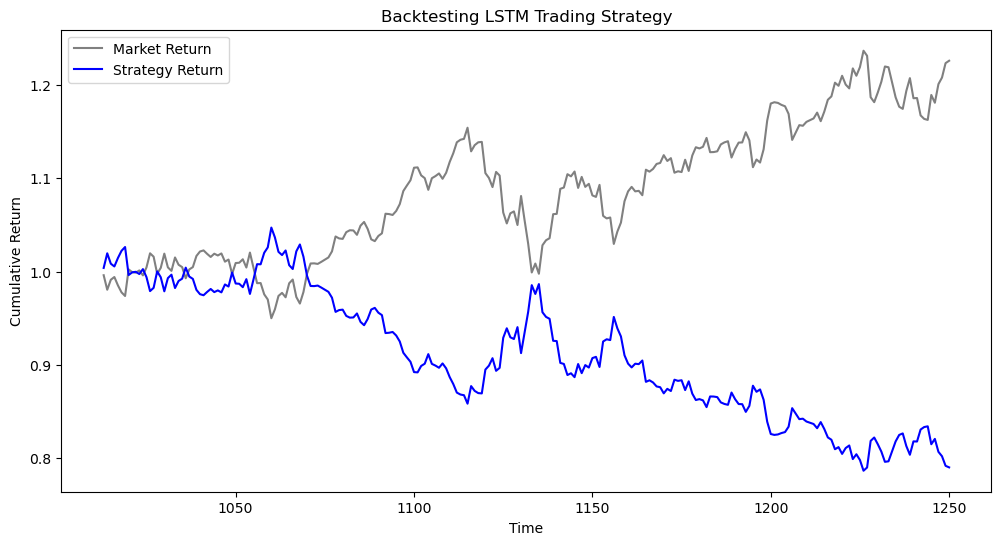

In [3]:
# LSTM next day return prediction

# Load dataset
df = pd.read_csv("qqq.csv")

# Feature Engineering
df["Return"] = df["close"].pct_change()
df["SMA_10"] = df["close"].rolling(window=10).mean()
df["SMA_50"] = df["close"].rolling(window=50).mean()
df["Volatility"] = df["Return"].rolling(window=10).std()
df["RSI"] = ta.momentum.RSIIndicator(df["close"], window=14).rsi()
df["MACD"] = ta.trend.MACD(df["close"]).macd()
df["Bollinger_Upper"] = ta.volatility.BollingerBands(df["close"]).bollinger_hband()
df["Bollinger_Lower"] = ta.volatility.BollingerBands(df["close"]).bollinger_lband()
df.dropna(inplace=True)

# Normalize Data
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[["close", "SMA_10", "SMA_50", "Volatility", "RSI", "MACD", "Bollinger_Upper", "Bollinger_Lower"]])

# Create sequences (past 20 days → next day's price)
seq_length = 20
X, y = [], []
for i in range(len(df_scaled) - seq_length):
    X.append(df_scaled[i:i+seq_length])
    y.append(df_scaled[i+seq_length][0])  # Predicting Close price

X, y = np.array(X), np.array(y)

# Train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build LSTM model
def build_lstm_model(units=50, dropout_rate=0.2, learning_rate=0.001):
    model = keras.Sequential([
        keras.layers.LSTM(units, return_sequences=True, input_shape=(seq_length, X.shape[2])),
        keras.layers.Dropout(dropout_rate),
        keras.layers.LSTM(units, return_sequences=False),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(25),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
    return model

# Train model with tuned hyperparameters
model = build_lstm_model(units=100, dropout_rate=0.3, learning_rate=0.0005)
model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test))

# Predictions
y_pred = model.predict(X_test)
y_pred_rescaled = scaler.inverse_transform(np.hstack([y_pred, np.zeros((len(y_pred), X.shape[2] - 1))]))[:, 0]

print("Predictions:", y_pred_rescaled[:5])

# Adjust df_test to match the length of y_pred_rescaled
df_test = df_test.iloc[:len(y_pred_rescaled)].copy()

df_test["Predicted_Close"] = y_pred_rescaled
df_test["Signal"] = np.where(df_test["Predicted_Close"] > df_test["close"], 1, -1)
df_test["Strategy_Return"] = df_test["Signal"] * df_test["Return"]

# Calculate cumulative returns
df_test["Cumulative_Strategy"] = (1 + df_test["Strategy_Return"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test["Cumulative_Market"], label="Market Return", color="gray")
plt.plot(df_test.index, df_test["Cumulative_Strategy"], label="Strategy Return", color="blue")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.title("Backtesting LSTM Trading Strategy")
plt.show()



In [6]:
def sharpe_ratio(returns, risk_free_rate=0.00):
    mean_return = np.mean(returns)
    std_return = np.std(returns)
    return (mean_return - risk_free_rate) / std_return

# Calculate Sharpe Ratio for XGBoost strategy
sharpe_xgb = sharpe_ratio(df_test["Strategy_Return"])
print(f"Sharpe Ratio (XGBoost Strategy): {sharpe_xgb:.2f}")

# Calculate Sharpe Ratio for LSTM strategy
sharpe_lstm = sharpe_ratio(df_test["Strategy_Return"])
print(f"Sharpe Ratio (LSTM Strategy): {sharpe_lstm:.2f}")


Sharpe Ratio (XGBoost Strategy): -0.08
Sharpe Ratio (LSTM Strategy): -0.08


In [7]:
def cagr(returns, periods_per_year=252):
    total_return = (1 + returns).cumprod().iloc[-1]
    num_years = len(returns) / periods_per_year
    return total_return ** (1 / num_years) - 1

def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

def win_rate(returns):
    return (returns > 0).mean()

# Compute performance metrics for XGBoost
cagr_xgb = cagr(df_test["Strategy_Return"])
max_dd_xgb = max_drawdown(df_test["Strategy_Return"])
win_rate_xgb = win_rate(df_test["Strategy_Return"])

print("XGBoost Strategy Performance:")
print(f"- CAGR: {cagr_xgb:.2%}")
print(f"- Max Drawdown: {max_dd_xgb:.2%}")
print(f"- Win Rate: {win_rate_xgb:.2%}")

# Compute performance metrics for LSTM
cagr_lstm = cagr(df_test["Strategy_Return"])
max_dd_lstm = max_drawdown(df_test["Strategy_Return"])
win_rate_lstm = win_rate(df_test["Strategy_Return"])

print("LSTM Strategy Performance:")
print(f"- CAGR: {cagr_lstm:.2%}")
print(f"- Max Drawdown: {max_dd_lstm:.2%}")
print(f"- Win Rate: {win_rate_lstm:.2%}")


XGBoost Strategy Performance:
- CAGR: -22.07%
- Max Drawdown: -24.88%
- Win Rate: 42.02%
LSTM Strategy Performance:
- CAGR: -22.07%
- Max Drawdown: -24.88%
- Win Rate: 42.02%


In [1]:
# Custom trading environment with stop-loss and risk management
class TradingEnvDQN(gym.Env):
    def __init__(self, df, stop_loss_pct=0.02, risk_per_trade=0.01, profit_target_pct=0.05):
        super(TradingEnvDQN, self).__init__()
        self.df = df
        self.current_step = 0
        self.balance = 10000  # Initial balance
        self.position = 0      # Number of shares held
        self.entry_price = 0    # Entry price of trade
        self.stop_loss_pct = stop_loss_pct  # Stop-loss level
        self.profit_target_pct = profit_target_pct  # Take-profit level
        self.risk_per_trade = risk_per_trade  # % of capital risked per trade
        self.done = False

        # Observation space: price, RSI, MACD, etc.
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(df.shape[1],), dtype=np.float32)

        # Action space: 0 = Hold, 1 = Buy, 2 = Sell
        self.action_space = spaces.Discrete(3)

    def step(self, action):
        price = self.df.iloc[self.current_step]["close"]
        reward = 0

        if action == 1 and self.position == 0:  # Buy
            self.entry_price = price
            risk_amount = self.balance * self.risk_per_trade
            self.position = risk_amount / price
            self.balance -= self.position * price

        elif action == 2 and self.position > 0:  # Sell
            self.balance += self.position * price
            self.position = 0
            self.entry_price = 0

        # Stop-Loss Logic
        if self.position > 0 and price <= self.entry_price * (1 - self.stop_loss_pct):
            self.balance += self.position * price  # Exit trade
            self.position = 0
            self.entry_price = 0
            reward -= 10  # Penalty for stop-loss triggered

        # Take-Profit Logic
        if self.position > 0 and price >= self.entry_price * (1 + self.profit_target_pct):
            self.balance += self.position * price  # Exit trade
            self.position = 0
            self.entry_price = 0
            reward += 10  # Reward for hitting profit target

        self.current_step += 1
        self.done = self.current_step >= len(self.df) - 1
        return self.df.iloc[self.current_step].values, reward, self.done, {}

    def reset(self):
        self.current_step = 0
        self.balance = 10000
        self.position = 0
        self.entry_price = 0
        return self.df.iloc[self.current_step].values

# Train DQN Agent

# Load dataset
df_test = df.iloc[len(X_train):-1].copy()  # Adjust the length to match y_pred

# Drop the datetime column as it cannot be converted to float
df_test_numeric = df_test.drop(columns=["datetime"])

env = TradingEnvDQN(df_test_numeric)
model = DQN("MlpPolicy", env, verbose=1, learning_rate=0.0001, buffer_size=10000, batch_size=32, exploration_fraction=0.1)
model.learn(total_timesteps=50000)

# Test the DQN Agent
obs = env.reset()
done = False
while not done:
    action, _ = model.predict(obs)
    obs, reward, done, _ = env.step(action)

print(f"Final Portfolio Value: {env.balance + env.position * df_test.iloc[-1]['close']}")


NameError: name 'gym' is not defined

In [16]:
df.describe()

,open,high,low,close,volume,Return,SMA_10,SMA_50,Volatility,RSI,MACD,Bollinger_Upper,Bollinger_Lower
count,1206.000000,1206.000000,1206.000000,1206.000000,1.206000e+03,1206.000000,1206.000000,1206.000000,1206.000000,1206.000000,1206.000000,1206.000000,1206.000000
mean,355.335182,358.055746,352.338226,350.439610,4.876086e+07,0.000909,349.198930,343.746795,0.013394,55.590571,1.908487,363.214110,332.399508
std,74.768475,74.725248,74.601726,76.227148,2.083317e+07,0.014373,75.874023,74.454689,0.005744,11.253537,4.630778,76.578207,75.172992
min,207.230000,211.160000,203.630000,199.130000,1.533400e+07,-0.054828,189.645000,194.310800,0.003120,23.509422,-12.565835,203.804460,161.595567
25%,296.952500,299.932500,293.287500,291.782500,3.392172e+07,-0.006878,291.639750,289.405150,0.009025,47.407057,-1.088846,306.739924,274.004610
50%,346.160000,348.880000,340.720000,339.795000,4.543565e+07,0.001302,337.854000,333.973500,0.012448,56.975613,3.059370,358.042969,320.467453
75%,396.577500,399.470000,393.487500,389.162500,5.878115e+07,0.009559,386.227750,378.216800,0.016705,63.752629,5.264792,398.465651,374.425599
max,536.360000,539.150000,534.130000,537.300000,1.986858e+08,0.073761,526.696000,516.987000,0.032276,81.590768,10.217035,538.964844,509.820028
